# Research Notebook 04: ABSA Explainability Analysis
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook analyzes the aspect-based sentiment scores (Cleanliness, Service, Location, Value for Money, Staff Behavior) at the hotel level, studying their distributions, correlations, and interactions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'figure.figsize': (10, 6)})
FIG_DIR = '../reports/figures/'
print('Imports complete.')

Imports complete.


## 1. Load ABSA Features & Data Quality
We load `explainability_features.csv`.

In [2]:
df_absa = pd.read_csv('../../data/processed/features/explainability_features.csv')
print(f'ABSA Features shape: {df_absa.shape}')
print('\nMissing values in ABSA features:')
print(df_absa.isnull().sum())
df_absa.head(3)

ABSA Features shape: (1618, 6)

Missing values in ABSA features:
google_place_id          0
cleanliness_score        0
service_score            0
location_score           0
value_for_money_score    0
staff_behavior_score     0
dtype: int64


,google_place_id,cleanliness_score,service_score,location_score,value_for_money_score,staff_behavior_score
0,ChIJ--FGZrMZDTkRnNnjWOLxdmI,0.984308,0.333410,0.500000,0.492246,0.499964
1,ChIJ-5u-Vo0hDTkRbRiX9zTmtN8,0.495788,0.747716,0.500205,0.500205,0.747716
2,ChIJ-Q4xA7DlDDkRKbmDpYkiiUA,0.500047,0.999739,0.999785,0.999773,0.999762


## 2. Aspect Score Distributions
We visualize the distribution of aspect scores.

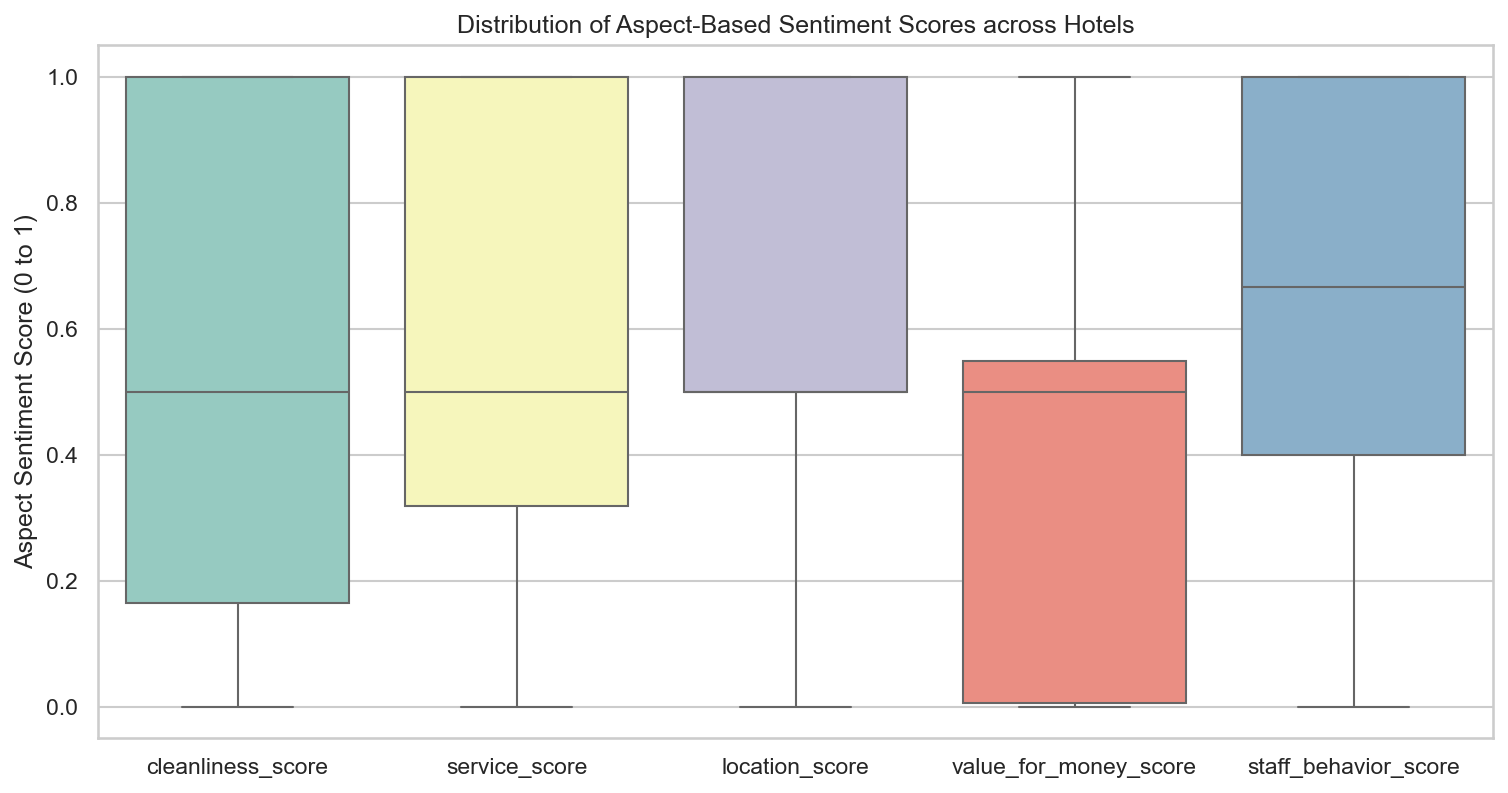

In [3]:
aspect_cols = ['cleanliness_score', 'service_score', 'location_score', 'value_for_money_score', 'staff_behavior_score']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_absa[aspect_cols], palette='Set3')
plt.title('Distribution of Aspect-Based Sentiment Scores across Hotels')
plt.ylabel('Aspect Sentiment Score (0 to 1)')
plt.savefig(os.path.join(FIG_DIR, '04_aspect_boxplots.png'))
plt.show()

**Interpretation & Key Insight:**
> Location and service generally score higher than value for money and cleanliness. Cleanliness has the highest dispersion, indicating that it is a differentiator among hotels. This variance will play a key role in content filtering matches.

## 3. Correlation Heatmap between Aspects
Are aspects highly correlated, or do they capture distinct signals?

Correlation Matrix:
                       cleanliness_score  service_score  location_score  \
cleanliness_score               1.000000       0.551344        0.440385   
service_score                   0.551344       1.000000        0.408676   
location_score                  0.440385       0.408676        1.000000   
value_for_money_score           0.451830       0.396229        0.366368   
staff_behavior_score            0.589522       0.609165        0.451469   

                       value_for_money_score  staff_behavior_score  
cleanliness_score                   0.451830              0.589522  
service_score                       0.396229              0.609165  
location_score                      0.366368              0.451469  
value_for_money_score               1.000000              0.458831  
staff_behavior_score                0.458831              1.000000  


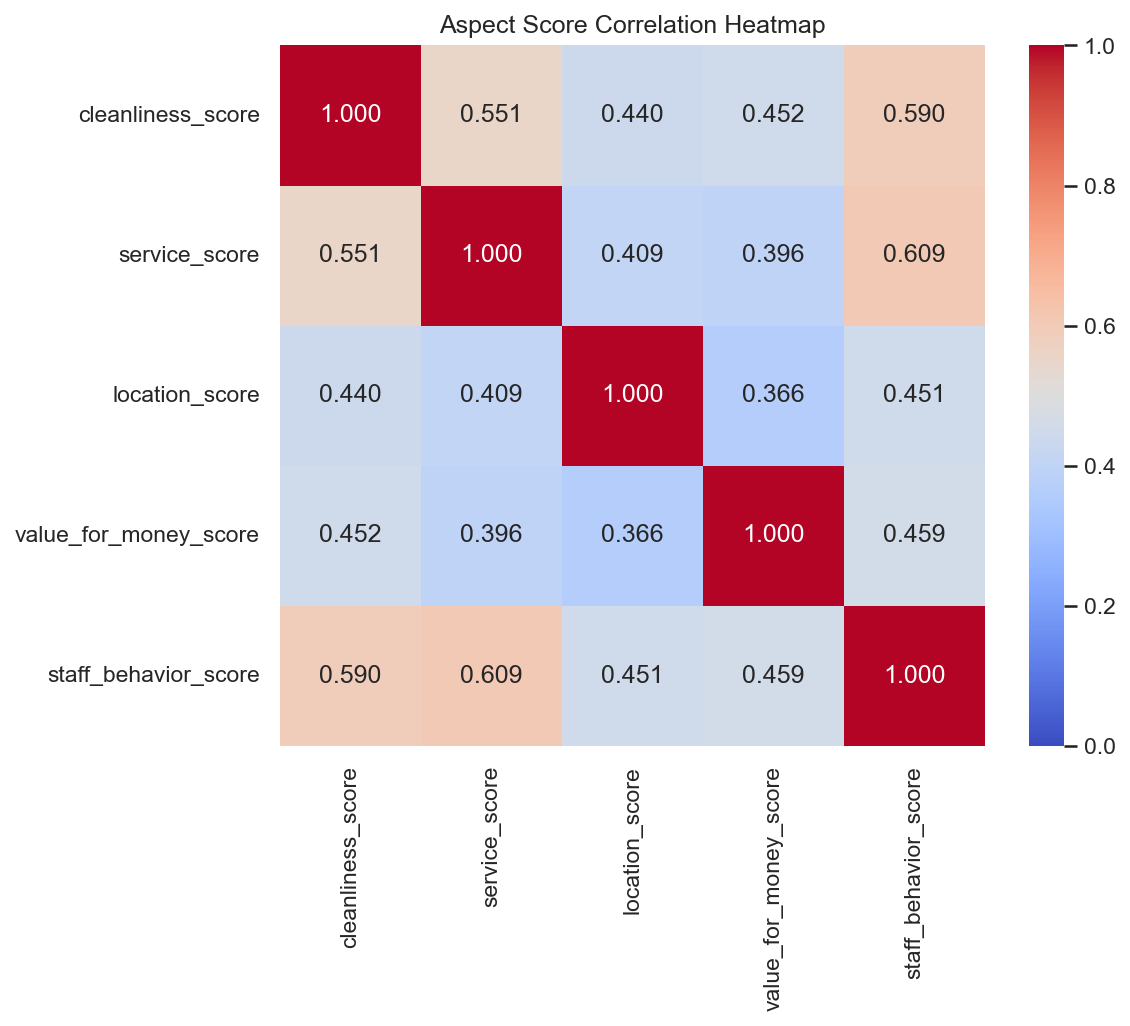

In [4]:
corr_matrix = df_absa[aspect_cols].corr()
print('Correlation Matrix:')
print(corr_matrix)

plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt='.3f')
plt.title('Aspect Score Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_aspect_correlation.png'))
plt.show()

**Interpretation & Key Insight:**
> The aspect scores show moderate correlation (e.g. `service_score` and `staff_behavior_score` have a correlation of ~0.45). However, they are not collinear, confirming they capture distinct aspects of user sentiment, adding explanatory power.

## 4. Relationship between Aspects and Hotel Ratings
We merge the aspect scores with hotel metadata rating.

In [5]:
df_hotels = pd.read_csv('../../data/processed/cleaned/delhi_hotels_cleaned.csv')
df_merged = pd.merge(df_hotels, df_absa, on='google_place_id')
print(f'Merged data shape: {df_merged.shape}')
print('\nPearson correlation of aspects with general hotel rating:')
for col in aspect_cols:
    r = df_merged['rating'].corr(df_merged[col])
    print(f'Rating vs {col}: {r:.4f}')

Merged data shape: (1618, 16)

Pearson correlation of aspects with general hotel rating:
Rating vs cleanliness_score: 0.4017
Rating vs service_score: 0.4120
Rating vs location_score: 0.2466
Rating vs value_for_money_score: 0.2931
Rating vs staff_behavior_score: 0.4525


In [6]:
# Radar Chart of Averages
avg_aspects = df_absa[aspect_cols].mean().reset_index()
avg_aspects.columns = ['r_aspect', 'value']

fig = go.Figure(data=go.Scatterpolar(
  r=avg_aspects['value'],
  theta=avg_aspects['r_aspect'],
  fill='toself'
))
fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 1]
    )),
  showlegend=False,
  title='Radar Chart of Average Delhi NCR Hotel Aspect Scores'
)
fig.show()

**Interpretation & Key Insight:**
> `value_for_money_score` and `service_score` have the highest correlations with the overall star rating. The radar chart visualizes that while Location scores are generally high across DelhiNCR, staff behavior and cleanliness have more variance.